In [53]:
import numpy as np
import matplotlib.pyplot as plt

### Імпорт і бінаризація зображень

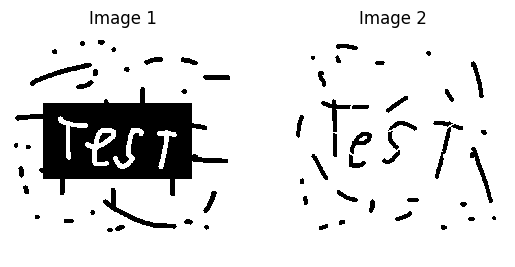

In [54]:
def to_binary(img):
    if img.ndim == 3:
        img = img.mean(axis=2)
    return (img > 128).astype(np.uint8)

img1_path = 'image1.jpg'
img2_path = 'image2.jpg'

img1_raw = plt.imread(img1_path)
img2_raw = plt.imread(img2_path)

img1_raw = to_binary(img1_raw)
img2_raw = to_binary(img2_raw)

plt.subplot(1, 2, 1)
plt.title('Image 1')
plt.axis('off')
plt.imshow(img1_raw, cmap='gray', interpolation='nearest')

plt.subplot(1, 2, 2)
plt.title('Image 2')
plt.axis('off')
plt.imshow(img2_raw, cmap='gray', interpolation='nearest')

## 1. Erosion (ерозiя).

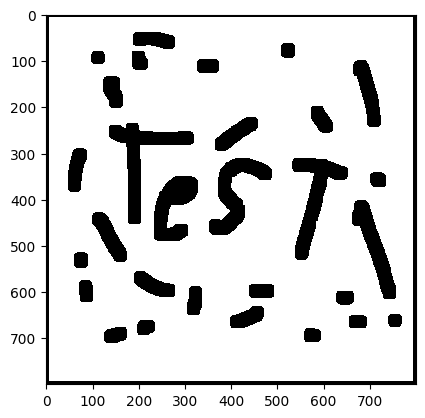

In [55]:
def erosion(img_raw, se):
    padded_img = np.pad(img_raw, ((se.shape[0]//2, se.shape[0]//2), (se.shape[1]//2, se.shape[1]//2)), mode='constant', constant_values=0)
    result = np.zeros_like(img_raw)
    for i in range(img_raw.shape[0]):
        for j in range(img_raw.shape[1]):
                region = padded_img[i:i + se.shape[0], j:j + se.shape[1]]
                if np.all(region[se == 1] == 1):
                    result[i, j] = 1
                else:
                    result[i, j] = 0
    return result

se1 = np.ones((15,15), dtype=np.uint8)

plt.imshow(erosion(img2_raw, se1), cmap='gray', interpolation='nearest')

## 2. Dilation (нарощування)

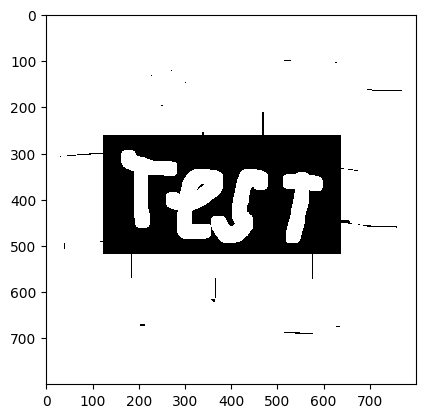

In [56]:
def dilation(img_raw, se):
    padded_img = np.pad(img_raw, ((se.shape[0]//2, se.shape[0]//2), (se.shape[1]//2, se.shape[1]//2)), mode='constant', constant_values=0)
    result = np.zeros_like(img_raw)
    for i in range(img_raw.shape[0]):
        for j in range(img_raw.shape[1]):
                region = padded_img[i:i + se.shape[0], j:j + se.shape[1]]
                result[i, j] = np.max(region[se == 1])
    return result

plt.imshow(dilation(img1_raw, se1), cmap='gray', interpolation='nearest')

## 3. Opening (розмикання).

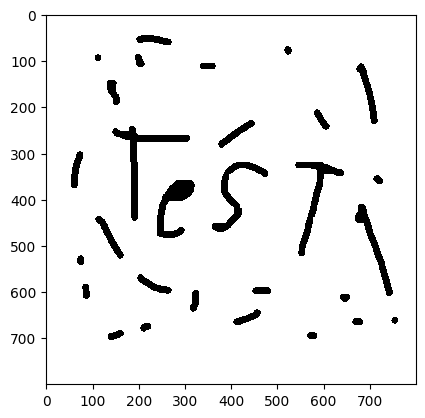

In [57]:
plt.imshow(dilation(erosion(img2_raw, se1), se1), cmap='gray', interpolation='nearest')

## 4. Closing (замикання).

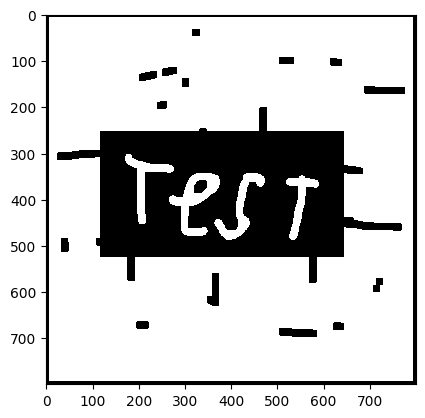

In [58]:
plt.imshow(erosion(dilation(img1_raw, se1), se1), cmap='gray', interpolation='nearest')

## 5. Границi.

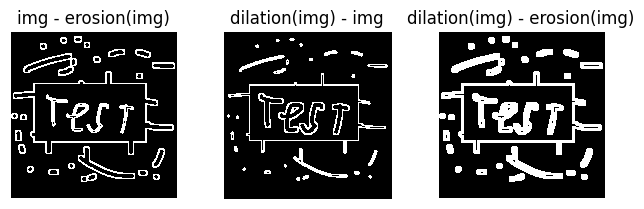

In [59]:
plt.subplot(1, 3, 1)
plt.tight_layout()
plt.axis('off')
plt.title('img - erosion(img)')
plt.imshow((img1_raw - erosion(img1_raw, se1)).clip(0, 1), cmap='gray', interpolation='nearest')

plt.subplot(1, 3, 2)
plt.tight_layout()
plt.title('dilation(img) - img')
plt.axis('off')
plt.imshow((dilation(img1_raw, se1) - img1_raw).clip(0, 1), cmap='gray', interpolation='nearest')

plt.subplot(1, 3, 3)
plt.tight_layout()
plt.title('dilation(img) - erosion(img)')
plt.axis('off')
plt.imshow((dilation(img1_raw, se1) - erosion(img1_raw, se1)).clip(0, 1), cmap='gray', interpolation='nearest')